# Observation-series + intelligence-report r-GCN → relation-aware HGT classification with LLM explanations

This notebook is a copy of `observation_series_and_intel_rgcn_classification_advanced_network.ipynb` that replaces its GraphSAGE neighbourhood layers with relation-aware r-GCN layers. The HGT attention stage and the paired categorical and Dirichlet/Dempster–Shafer (DS) output heads are retained.

After inference, an evidence-grounded LLM explanation layer served by a local Ollama instance attempts to identify the emitter from aircraft, operator, radar, and radar-mode findings. Its prompt receives the GNN's raw evidence, belief, plausibility, uncertainty, and pignistic probability for the leading alternatives. It also explains the modified per-task DS frame—singleton label focal elements plus full-frame ignorance—so the LLM does not conflate committed support, compatible support, ignorance, or a decision probability. A deterministic safety policy labels the evidence and recommends active collection (including engaging an active RADAR) whenever uncertainty is extreme.

The supervised targets remain observation-level aircraft variant, radar mode, radar type, and operator country. Ground-truth labels and synthetic report truth markers are stripped from model features; report text-derived claim fields are treated as noisy external evidence. Candidate shortlists now use the production intelligence-aware pipeline: final signed claim compatibility is applied exactly once, independent sources are aggregated, sensor and claim masses are fused with Dempster–Shafer combination, and direct support/refutation relations participate in r-GCN/HGT message passing.


In [10]:
from __future__ import annotations

import json, math, os, random, sys, time
import urllib.error, urllib.parse, urllib.request
from collections import Counter, defaultdict
from dataclasses import dataclass
from datetime import UTC, datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.checkpoint
from torch import nn
import torch.nn.functional as F
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rgcn_fusion import attribute_assessments, decode_kg_constrained
from esm_observation_series_generator import load_observation_series_json
from rgcn_fusion.intelligence_reports import (
    aggregate_candidate_intelligence,
    report_claim_score,
    report_recency_score,
)
from kg_generator import generate_graph
from rgcn_fusion.observation_etl import ds_masses_from_score, score_candidates
DATA_PATH = ROOT / "generated" / "demo_esm_observation_series_with_intel.json"
ARTIFACT_DIR = ROOT / "artifacts" / "observation_series_and_intel_rgcn_classification_advanced_network_llm"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_PATH)
print(ARTIFACT_DIR)
print(DEVICE)



C:\Users\theon\r-GCN_fusion\generated\demo_esm_observation_series_with_intel.json
C:\Users\theon\r-GCN_fusion\artifacts\observation_series_and_intel_rgcn_classification_advanced_network_llm
cuda


## Load series and create a label-free inference view

Ground-truth fields are retained in a separate target table, but are recursively stripped from the feature payload before graph construction. This prevents leakage from `ground_truth_label`, `ground_truth_track_label`, and `ground_truth_mode_sequence` into node features or edges.



In [11]:
LEAKAGE_KEYS = {"ground_truth_label", "ground_truth_track_label", "ground_truth_mode_sequence", "synthetic_truth_value"}
TARGETS = ["aircraft_variant", "radar_mode", "radar_type", "operator_country"]

def strip_ground_truth(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {k: strip_ground_truth(v) for k, v in obj.items() if k not in LEAKAGE_KEYS}
    if isinstance(obj, list):
        return [strip_ground_truth(v) for v in obj]
    return obj

raw = load_observation_series_json(DATA_PATH)
series_records = raw["observation_series"]
inference_records = strip_ground_truth(series_records)

# Targets are extracted only from the original payload and never merged back into features.
target_rows = []
for s in series_records:
    for obs in s["observations"]:
        gt = obs["ground_truth_label"]
        target_rows.append({
            "observation_id": obs["observation_id"],
            "series_id": obs["series_id"],
            "sequence_index": obs["sequence_index"],
            "aircraft_variant": gt.get("aircraft_variant"),
            "radar_mode": gt.get("mode") or gt.get("radar_mode"),
            "radar_type": gt.get("radar") or gt.get("radar_type"),
            "operator_country": gt.get("operator") or gt.get("operator_country"),
        })

serialized_features = json.dumps(inference_records)
assert "ground_truth" not in serialized_features, "Ground-truth fields leaked into inference view"
report_count = sum(len(series.get("intelligence_reports") or []) for series in series_records)
print(f"series={len(series_records):,}, observations={len(target_rows):,}, intelligence_reports={report_count:,}")
print(target_rows[0])



series=2,500, observations=117,665, intelligence_reports=12,467
{'observation_id': 'esm_series_00001_obs_001', 'series_id': 'esm_series_00001', 'sequence_index': 0, 'aircraft_variant': 'F-16V Block 70/72', 'radar_mode': 'look_down_shoot_down', 'radar_type': 'AN/APG-83 SABR', 'operator_country': 'Slovakia'}


## Feature engineering with sensor and intelligence-aware candidate evidence

Observation features continue to use only measured ESM parameters, approximate kinematics, elapsed time, and sensor metadata from the label-free inference view. Candidate nodes retain their original sensor score and add final-signed report compatibility, provenance-deduplicated support/refutation, conflict, uncertainty, fused DS masses, and an intelligence-aware final score. The candidate shortlist is re-ranked only after these components have been calculated. No synthetic truth marker is used in compatibility or fusion.

Optional segment IDs remain derived only from measured radar-parameter changes; segment edges stay disabled by default for the cleanest benchmark.


In [ ]:
INCLUDE_CANDIDATE_NODES = True
INCLUDE_INTEL_REPORT_NODES = True
USE_SEGMENT_EDGES = False
SEGMENT_FREQUENCY_SHIFT_GHZ = 0.75
MAX_KG_CANDIDATES = 5
GRAPH_INPUT_ARTIFACT = ARTIFACT_DIR / "graph_construction_outputs.pt"
X_NP_DTYPE, TORCH_DATA_DTYPE = np.float16, torch.float16

kg = generate_graph()
kg_nodes = {node["id"]: node for node in kg["nodes"]}
radar_by_mode = {edge["target"]: edge["source"] for edge in kg["edges"] if edge["relation"] == "HAS_MODE"}
aircraft_by_radar: dict[str, list[str]] = defaultdict(list)
operators_by_aircraft: dict[str, list[str]] = defaultdict(list)
aircraft_family_by_aircraft: dict[str, str] = {}
for edge in kg["edges"]:
    if edge["relation"] == "USES_RADAR":
        aircraft_by_radar[edge["target"]].append(edge["source"])
    elif edge["relation"] == "OPERATES":
        operators_by_aircraft[edge["target"]].append(kg_nodes[edge["source"]]["properties"].get("name"))
    elif edge["relation"] == "VARIANT_OF":
        aircraft_family_by_aircraft[edge["source"]] = edge["target"]
kg_candidate_rows = [
    {
        "mode_id": mode_id, "mode_props": kg_nodes[mode_id]["properties"],
        "radar_id": radar_id, "radar_props": kg_nodes[radar_id]["properties"],
        "aircraft_id": aircraft_id,
        "aircraft_props": kg_nodes[aircraft_id]["properties"] if aircraft_id else None,
        "aircraft_uses_radar": aircraft_id is not None, "operator": operator,
    }
    for mode_id, radar_id in radar_by_mode.items()
    for aircraft_id in (aircraft_by_radar.get(radar_id) or [None])
    for operator in (operators_by_aircraft.get(aircraft_id, [None]) if aircraft_id else [None])
]

# Elementary DS worlds are complete, mutually exclusive KG-valid configurations.
# Aircraft family is projected from the joint frame rather than trained as an
# unrelated head, preserving its deterministic relationship to the variant.
kg_valid_worlds = []
seen_kg_worlds = set()
for row in kg_candidate_rows:
    if not row["aircraft_id"] or not row["operator"]:
        continue
    world = {
        "radar_mode": row["mode_props"].get("name"),
        "radar_type": row["radar_props"].get("name"),
        "aircraft_variant": row["aircraft_props"].get("variant"),
        "aircraft_family": row["aircraft_props"].get("family"),
        "operator_country": row["operator"],
    }
    key = tuple(world[name] for name in ("radar_mode", "radar_type", "aircraft_variant", "aircraft_family", "operator_country"))
    if None not in key and key not in seen_kg_worlds:
        seen_kg_worlds.add(key)
        kg_valid_worlds.append(world)
print(f"KG-valid joint frame: {len(kg_valid_worlds):,} elementary worlds")

# score_candidates repeats the same mode/aircraft calculation once per operator.
# Score one template per mode/radar/aircraft tuple, then expand its operator variants.
candidate_variants: dict[tuple[str, str | None, str | None], list[dict[str, Any]]] = defaultdict(list)
for row in kg_candidate_rows:
    candidate_variants[(row["mode_id"], row["radar_id"], row["aircraft_id"])].append(row)
candidate_templates = [{**rows[0], "operator": None} for rows in candidate_variants.values()]


def flatten_numeric(prefix: str, value: Any, out: dict[str, float]) -> None:
    if isinstance(value, dict):
        for k, v in value.items():
            flatten_numeric(f"{prefix}.{k}" if prefix else k, v, out)
    elif isinstance(value, (int, float)) and not isinstance(value, bool):
        out[prefix] = float(value)


def _numeric_value(value: Any) -> float | None:
    if isinstance(value, dict):
        value = value.get("value")
    return float(value) if isinstance(value, (int, float)) and not isinstance(value, bool) else None


def segment_indices(observations: list[dict[str, Any]]) -> list[int]:
    """Infer coarse transition markers from measured frequency only, never labels/candidates."""
    frequencies = [_numeric_value(obs.get("esm_radar_parameters", {}).get("measured_centre_frequency_ghz")) for obs in observations]
    segments, current = [], 0
    for index, frequency in enumerate(frequencies):
        if index and frequency is not None and frequencies[index - 1] is not None and abs(frequency - frequencies[index - 1]) > SEGMENT_FREQUENCY_SHIFT_GHZ:
            current += 1
        segments.append(current)
    return segments


def candidate_scores_for_observation(obs: dict[str, Any]):
    """Avoid rescoring identical mode/radar/aircraft templates for every operator."""
    template_scores = score_candidates(obs, candidate_templates, max_candidates=len(candidate_templates))
    expanded = []
    context = obs.get("external_context") or {}
    priors = context.get("priors") if isinstance(context.get("priors"), dict) else {}
    operator_priors = context.get("operator_priors", priors.get("operator", {})) if isinstance(context, dict) else {}
    contextual_operator = context.get("operator") if isinstance(context, dict) else None
    for score in template_scores:
        for row in candidate_variants[(score.mode_id, score.radar_id, score.aircraft_id)]:
            operator = row["operator"]
            if isinstance(operator_priors, dict) and operator in operator_priors:
                operator_score = max(0.0, min(1.0, float(operator_priors[operator])))
            elif isinstance(contextual_operator, (list, tuple, set)):
                operator_score = 1.0 if operator in contextual_operator else 0.0
            elif contextual_operator is None:
                operator_score = 0.5
            else:
                operator_score = 1.0 if operator == contextual_operator else 0.0
            expanded.append((round(0.75 * score.mode_score + 0.15 * score.aircraft_score + 0.10 * operator_score, 6), score, operator))
    return sorted(expanded, key=lambda item: item[0], reverse=True)[:MAX_KG_CANDIDATES]



feature_rows, node_meta = [], []
observation_node_indices: list[int] = []
candidates_by_observation_node: dict[int, list[int]] = defaultdict(list)
reports_by_observation_node: dict[int, list[int]] = defaultdict(list)
claims_by_observation_node: dict[int, list[int]] = defaultdict(list)
claims_by_claim_type: dict[tuple[str, str], list[int]] = defaultdict(list)
claim_candidate_edges: list[dict[str, Any]] = []


In [ ]:

# Append every node in one traversal: this removes two large pending-node lists and
# parses each report timestamp exactly once, rather than once per claim.
for series in inference_records:
    obs_list = sorted(series["observations"], key=lambda obs: obs["sequence_index"])
    n = max(len(obs_list), 1)
    for obs, segment in zip(obs_list, segment_indices(obs_list)):
        obs_node_idx = len(feature_rows)
        observation_node_indices.append(obs_node_idx)
        feats = {
            "node_kind_observation": 1.0, "node_kind_candidate": 0.0,
            "elapsed_time_s": float(obs.get("elapsed_time_s", 0.0)),
            "sequence_fraction": float(obs.get("sequence_index", 0)) / max(n - 1, 1),
            "segment_index": float(segment), "duration_s": float(series.get("duration_s", 0.0)),
            "observation_count": float(series.get("observation_count", n)),
        }
        flatten_numeric("esm", obs.get("esm_radar_parameters", {}), feats)
        flatten_numeric("kin", obs.get("approximate_kinematics", {}), feats)
        flatten_numeric("loc", obs.get("estimated_emitter_location", {}), feats)
        feature_rows.append(feats)
        timestamp = obs.get("timestamp_iso8601")
        observation_time = datetime.fromisoformat(timestamp.replace("Z", "+00:00")).astimezone(UTC) if timestamp else None
        obs_meta = {"node_kind": "observation", "observation_id": obs["observation_id"], "series_id": obs["series_id"], "sequence_index": obs["sequence_index"], "timestamp_iso8601": timestamp}
        node_meta.append(obs_meta)

        if INCLUDE_INTEL_REPORT_NODES and obs is obs_list[0]:
            for report_rank, report in enumerate(series.get("intelligence_reports") or [], start=1):
                recency = report_recency_score(report, reference_time=observation_time)
                report_idx = len(feature_rows)
                feature_rows.append({"node_kind_observation": 0.0, "node_kind_candidate": 0.0, "node_kind_report": 1.0, "node_kind_claim": 0.0, "report_rank": float(report_rank), "report_credibility_score": float(report.get("credibility_score", 0.5)), "report_recency_score": float(recency), "report_claim_count": float(len(report.get("claims") or []))})
                node_meta.append({"node_kind": "intelligence_report", "report_id": report["report_id"], "observation_node_indices": [], "series_id": obs_meta["series_id"]})
                for claim_rank, claim in enumerate(report.get("claims") or [], start=1):
                    claim_idx = len(feature_rows)
                    claim_score = report_claim_score(report, claim, observation_time=observation_time)
                    feature_rows.append({"node_kind_observation": 0.0, "node_kind_candidate": 0.0, "node_kind_report": 0.0, "node_kind_claim": 1.0, "claim_rank": float(claim_rank), "claim_confidence": float(claim.get("claim_confidence", 0.5)), "claim_extraction_confidence": float(claim.get("extraction_confidence", 0.5)), "claim_specificity_score": float(claim.get("specificity_score", 0.5)), "claim_kg_consistency_score": float(claim.get("kg_consistency_score", 0.5)), "claim_text_score": float(claim_score), "claim_supports": 1.0 if claim.get("stance", "supports") == "supports" else 0.0, "claim_refutes": 1.0 if claim.get("stance") == "refutes" else 0.0})
                    node_meta.append({"node_kind": "report_claim", "id": f"evidence:claim:{claim['claim_id']}", "claim_id": claim["claim_id"], "claim_type": claim.get("claim_type"), "object_id": claim.get("object_id"), "stance": claim.get("stance", "supports"), "text_score": claim_score, "source_id": report.get("source_id"), "report_id": report.get("report_id"), "report_node_idx": report_idx, "observation_node_indices": [], "series_id": obs_meta["series_id"]})

        if INCLUDE_CANDIDATE_NODES:
            # Claims are scored at this observation time, then passed to the shared
            # production aggregation function. Compatibility is already final and
            # signed, so no additional stance multiplier is applied in the notebook.
            applicable_claims = []
            for report in series.get("intelligence_reports") or []:
                for claim in report.get("claims") or []:
                    applicable_claims.append({
                        **claim,
                        "id": f"evidence:claim:{claim['claim_id']}",
                        "report_id": report.get("report_id"),
                        "source_id": report.get("source_id"),
                        "series_id": obs_meta["series_id"],
                        "text_score": report_claim_score(report, claim, observation_time=observation_time),
                    })

            enriched_candidates = []
            for sensor_rank, (sensor_score, score, operator) in enumerate(candidate_scores_for_observation(obs), start=1):
                candidate_id = f"candidate:{obs_meta['observation_id']}:{sensor_rank}"
                candidate = {
                    "id": candidate_id,
                    "observation_id": obs_meta["observation_id"],
                    "series_id": obs_meta["series_id"],
                    "mode_id": score.mode_id,
                    "radar_id": score.radar_id,
                    "aircraft_id": score.aircraft_id,
                    "aircraft_family_id": aircraft_family_by_aircraft.get(score.aircraft_id),
                    "operator": operator,
                    "relation_id": f"relation:{score.aircraft_id}:USES_RADAR:{score.radar_id}",
                    "sensor_score": sensor_score,
                    "sensor_ds_masses": ds_masses_from_score(sensor_score, 0.2 if sensor_rank == 1 else 0.35),
                }
                intelligence, direct_edges = aggregate_candidate_intelligence(candidate, applicable_claims)
                enriched_candidates.append((intelligence["final_score"], sensor_rank, score, operator, candidate, intelligence, direct_edges))

            enriched_candidates.sort(key=lambda item: item[0], reverse=True)
            candidate_count = len(enriched_candidates)
            for rank, (_final_score, sensor_rank, score, operator, candidate, intelligence, direct_edges) in enumerate(enriched_candidates, start=1):
                candidate_idx = len(feature_rows)
                intel_features = {
                    f"candidate_{name}": float(intelligence[name])
                    for name in (
                        "sensor_score", "intel_support_score", "intel_refute_score",
                        "intel_net_score", "intel_score", "intel_conflict",
                        "intel_uncertainty", "intel_claim_count", "intel_source_count",
                        "intel_effective_weight", "final_score",
                    )
                }
                fused_non_match, fused_match, fused_uncertain = intelligence["ds_masses"]
                feature_rows.append({"node_kind_observation": 0.0, "node_kind_candidate": 1.0, "candidate_rank": float(rank), "candidate_sensor_rank": float(sensor_rank), "candidate_rank_fraction": float(rank - 1) / max(candidate_count - 1, 1), "candidate_count": float(candidate_count), "candidate_mode_score": float(score.mode_score), "candidate_aircraft_score": float(score.aircraft_score), "candidate_total_score": float(intelligence["final_score"]), "candidate_fused_non_match_mass": float(fused_non_match), "candidate_fused_match_mass": float(fused_match), "candidate_fused_uncertain_mass": float(fused_uncertain), "candidate_matched_fields": float(score.matched_fields), "candidate_compared_fields": float(score.compared_fields), **intel_features, **{f"candidate_{name}": float(value) for name, value in (getattr(score, "feature_scores", None) or {}).items()}})
                node_meta.append({"node_kind": "candidate", "candidate_id": candidate["id"], "observation_node_idx": obs_node_idx, "observation_id": obs_meta["observation_id"], "series_id": obs_meta["series_id"], "sequence_index": obs_meta["sequence_index"], "rank": rank, "sensor_rank": sensor_rank, "mode_id": score.mode_id, "radar_id": score.radar_id, "aircraft_id": score.aircraft_id, "operator": operator, "sensor_score": intelligence["sensor_score"], "intel_score": intelligence["intel_score"], "intel_support_score": intelligence["intel_support_score"], "intel_refute_score": intelligence["intel_refute_score"], "intel_conflict": intelligence["intel_conflict"], "intel_uncertainty": intelligence["intel_uncertainty"], "final_score": intelligence["final_score"], "fused_ds_masses": intelligence["ds_masses"], "claim_evidence": direct_edges})
                candidates_by_observation_node[obs_node_idx].append(candidate_idx)
                claim_candidate_edges.extend({**edge, "candidate_node_idx": candidate_idx} for edge in direct_edges)

# Shared reports/claims apply to every observation node in their series.
for report_idx, meta in enumerate(node_meta):
    if meta.get("node_kind") != "intelligence_report":
        continue
    applicable = [idx for idx in observation_node_indices if node_meta[idx]["series_id"] == meta["series_id"]]
    meta["observation_node_indices"] = applicable
    for obs_idx in applicable:
        reports_by_observation_node[obs_idx].append(report_idx)
for claim_idx, meta in enumerate(node_meta):
    if meta.get("node_kind") != "report_claim":
        continue
    applicable = [idx for idx in observation_node_indices if node_meta[idx]["series_id"] == meta["series_id"]]
    meta["observation_node_indices"] = applicable
    for obs_idx in applicable:
        claims_by_observation_node[obs_idx].append(claim_idx)
        claims_by_claim_type[(node_meta[obs_idx]["observation_id"], str(meta.get("claim_type")))].append(claim_idx)

feature_names = sorted({key for row in feature_rows for key in row})
label_like_feature_names = [name for name in feature_names if any(token in name.lower() for token in ("ground_truth", "mode_id", "radar_mode", "aircraft_id", "operator_country", "synthetic_truth"))]
assert not label_like_feature_names, f"Label-like feature names leaked: {label_like_feature_names}"

X_np = np.asarray([[row.get(name, 0.0) for name in feature_names] for row in feature_rows], dtype=X_NP_DTYPE)
mu, sigma = X_np.astype(np.float32).mean(axis=0), X_np.astype(np.float32).std(axis=0)
sigma[sigma == 0] = 1.0
X = torch.tensor((X_np.astype(np.float32) - mu) / sigma, dtype=TORCH_DATA_DTYPE, device=DEVICE)

torch.save({"version": 2, "X": X.cpu(), "feature_names": feature_names, "feature_rows": feature_rows, "node_meta": node_meta, "observation_node_indices": observation_node_indices, "candidates_by_observation_node": dict(candidates_by_observation_node), "reports_by_observation_node": dict(reports_by_observation_node), "claims_by_observation_node": dict(claims_by_observation_node), "claims_by_claim_type": dict(claims_by_claim_type), "claim_candidate_edges": claim_candidate_edges, "include_candidate_nodes": INCLUDE_CANDIDATE_NODES, "include_intel_report_nodes": INCLUDE_INTEL_REPORT_NODES, "use_segment_edges": USE_SEGMENT_EDGES, "segment_frequency_shift_ghz": SEGMENT_FREQUENCY_SHIFT_GHZ, "max_kg_candidates": MAX_KG_CANDIDATES}, GRAPH_INPUT_ARTIFACT)
print(X.shape, feature_names[:10], {"observation_nodes": len(observation_node_indices), "candidate_nodes": sum(map(len, candidates_by_observation_node.values())), "report_nodes": sum(1 for meta in node_meta if meta.get("node_kind") == "intelligence_report"), "claim_nodes": sum(1 for meta in node_meta if meta.get("node_kind") == "report_claim"), "artifact": str(GRAPH_INPUT_ARTIFACT)})


In [ ]:
GRAPH_INPUT_ARTIFACT = ARTIFACT_DIR / "graph_construction_outputs.pt"

torch.save({"version": 2, "X": X.cpu(), "feature_names": feature_names, "feature_rows": feature_rows, "node_meta": node_meta, "observation_node_indices": observation_node_indices, "candidates_by_observation_node": dict(candidates_by_observation_node), "reports_by_observation_node": dict(reports_by_observation_node), "claims_by_observation_node": dict(claims_by_observation_node), "claims_by_claim_type": dict(claims_by_claim_type), "claim_candidate_edges": claim_candidate_edges, "include_candidate_nodes": INCLUDE_CANDIDATE_NODES, "include_intel_report_nodes": INCLUDE_INTEL_REPORT_NODES, "use_segment_edges": USE_SEGMENT_EDGES, "segment_frequency_shift_ghz": SEGMENT_FREQUENCY_SHIFT_GHZ, "max_kg_candidates": MAX_KG_CANDIDATES}, GRAPH_INPUT_ARTIFACT)
print(X.shape, feature_names[:10], {"observation_nodes": len(observation_node_indices), "candidate_nodes": sum(map(len, candidates_by_observation_node.values())), "report_nodes": sum(1 for meta in node_meta if meta.get("node_kind") == "intelligence_report"), "claim_nodes": sum(1 for meta in node_meta if meta.get("node_kind") == "report_claim"), "claim_candidate_edges": len(claim_candidate_edges), "artifact": str(GRAPH_INPUT_ARTIFACT)})


In [ ]:
# Reload graph-construction outputs instead of rebuilding the feature and evidence nodes.
GRAPH_INPUT_ARTIFACT = ARTIFACT_DIR / "graph_construction_outputs.pt"
graph_outputs = torch.load(GRAPH_INPUT_ARTIFACT, map_location="cpu", weights_only=False)
if graph_outputs.get("version") != 2:
    raise ValueError(f"Unsupported graph-construction artifact: {GRAPH_INPUT_ARTIFACT}")
X = graph_outputs["X"].to(device=DEVICE, dtype=torch.float16)
feature_names = graph_outputs["feature_names"]
feature_rows = graph_outputs["feature_rows"]
node_meta = graph_outputs["node_meta"]
observation_node_indices = graph_outputs["observation_node_indices"]
candidates_by_observation_node = defaultdict(list, graph_outputs["candidates_by_observation_node"])
reports_by_observation_node = defaultdict(list, graph_outputs["reports_by_observation_node"])
claims_by_observation_node = defaultdict(list, graph_outputs["claims_by_observation_node"])
claims_by_claim_type = defaultdict(list, graph_outputs["claims_by_claim_type"])
claim_candidate_edges = graph_outputs["claim_candidate_edges"]
print(f"Reloaded {X.size(0):,} nodes, {X.size(1):,} features from {GRAPH_INPUT_ARTIFACT}")


## Build the intelligence-aware relational graph

The graph contains temporal and same-emitter observation structure, ranked sensor/intelligence candidate hypotheses, report provenance, and claims. Candidate relations now include direct `claim_supports_candidate` and `claim_refutes_candidate` types (plus reverse relations) produced from final signed compatibility. This lets the relation-aware r-GCN/HGT distinguish positive intelligence from refutation instead of routing every claim through an observation first.

Optional segment/mode-shift edges remain an ablation because they may inflate a clean radar-mode benchmark.


In [ ]:
RELATION_NAMES = ["self", "next_observation", "prev_observation", "same_emitter"]
if USE_SEGMENT_EDGES:
    RELATION_NAMES.extend(["same_mode_segment", "possible_mode_shift"])
if INCLUDE_CANDIDATE_NODES:
    RELATION_NAMES.extend(["has_candidate", "candidate_for", "contradicts_candidate"])
if INCLUDE_INTEL_REPORT_NODES:
    RELATION_NAMES.extend(["has_report", "report_for", "report_contains_claim", "claim_from_report", "claim_supports_observation", "observation_supported_by_claim", "claim_supports_candidate", "candidate_supported_by_claim", "claim_refutes_candidate", "candidate_refuted_by_claim", "contradicts_claim"])
RELATIONS = {name: idx for idx, name in enumerate(RELATION_NAMES)}
edge_src, edge_dst, edge_type = [], [], []


def add_edge(i, j, rel):
    edge_src.append(i)
    edge_dst.append(j)
    edge_type.append(RELATIONS[rel])


def candidate_contradiction_reasons(left: dict[str, Any], right: dict[str, Any]) -> list[str]:
    comparisons = {"rank": (left.get("rank"), right.get("rank"))}
    return [field for field, (a, b) in comparisons.items() if a is not None and b is not None and a != b]


for i in range(len(node_meta)):
    add_edge(i, i, "self")

series_to_indices = defaultdict(list)
for i in observation_node_indices:
    series_to_indices[node_meta[i]["series_id"]].append(i)

segment_by_node = {i: int(feature_rows[i]["segment_index"]) for i in observation_node_indices}
for indices in series_to_indices.values():
    indices = sorted(indices, key=lambda i: node_meta[i]["sequence_index"])
    for a, b in zip(indices, indices[1:]):
        add_edge(a, b, "next_observation")
        add_edge(b, a, "prev_observation")
        if USE_SEGMENT_EDGES:
            if segment_by_node[a] == segment_by_node[b]:
                add_edge(a, b, "same_mode_segment")
                add_edge(b, a, "same_mode_segment")
            else:
                add_edge(a, b, "possible_mode_shift")
                add_edge(b, a, "possible_mode_shift")
    # Sparse same-emitter reinforcement edges between observations two samples apart.
    for a, b in zip(indices, indices[2:]):
        add_edge(a, b, "same_emitter")
        add_edge(b, a, "same_emitter")

contradiction_reasons = Counter()
if INCLUDE_CANDIDATE_NODES:
    for obs_idx, candidate_indices in candidates_by_observation_node.items():
        candidate_indices = sorted(candidate_indices, key=lambda idx: node_meta[idx]["rank"])
        for candidate_idx in candidate_indices:
            add_edge(obs_idx, candidate_idx, "has_candidate")
            add_edge(candidate_idx, obs_idx, "candidate_for")
        for left_pos, left_idx in enumerate(candidate_indices):
            for right_idx in candidate_indices[left_pos + 1:]:
                reasons = candidate_contradiction_reasons(node_meta[left_idx], node_meta[right_idx])
                if not reasons:
                    continue
                add_edge(left_idx, right_idx, "contradicts_candidate")
                contradiction_reasons.update(reasons)

if INCLUDE_INTEL_REPORT_NODES:
    for obs_idx, report_indices in reports_by_observation_node.items():
        for report_idx in report_indices:
            add_edge(obs_idx, report_idx, "has_report")
            add_edge(report_idx, obs_idx, "report_for")
    for obs_idx, claim_indices in claims_by_observation_node.items():
        for claim_idx in claim_indices:
            report_idx = node_meta[claim_idx]["report_node_idx"]
            add_edge(report_idx, claim_idx, "report_contains_claim")
            add_edge(claim_idx, report_idx, "claim_from_report")
            add_edge(claim_idx, obs_idx, "claim_supports_observation")
            add_edge(obs_idx, claim_idx, "observation_supported_by_claim")
    claim_node_by_id = {
        meta.get("id"): idx
        for idx, meta in enumerate(node_meta)
        if meta.get("node_kind") == "report_claim"
    }
    for direct_edge in claim_candidate_edges:
        claim_idx = claim_node_by_id.get(direct_edge["source"])
        candidate_idx = direct_edge["candidate_node_idx"]
        if claim_idx is None:
            continue
        if direct_edge["contribution"] > 0.0:
            add_edge(claim_idx, candidate_idx, "claim_supports_candidate")
            add_edge(candidate_idx, claim_idx, "candidate_supported_by_claim")
        elif direct_edge["contribution"] < 0.0:
            add_edge(claim_idx, candidate_idx, "claim_refutes_candidate")
            add_edge(candidate_idx, claim_idx, "candidate_refuted_by_claim")
    for claim_indices in claims_by_claim_type.values():
        for left_pos, left_idx in enumerate(claim_indices):
            for right_idx in claim_indices[left_pos + 1:]:
                if node_meta[left_idx].get("object_id") != node_meta[right_idx].get("object_id"):
                    add_edge(left_idx, right_idx, "contradicts_claim")
                    contradiction_reasons.update(["report_claim_object_id"])

edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long, device=DEVICE)
edge_types = torch.tensor(edge_type, dtype=torch.long, device=DEVICE)
print({name: int((edge_types == rid).sum().cpu()) for name, rid in RELATIONS.items()})
print({"contradiction_reasons": dict(contradiction_reasons)})




## Encode labels and create the required 0.5 / 0.3 / 0.2 train-test-validation split

Splitting is performed by `series_id`, not by individual observation, so adjacent observations from the same emitter track cannot cross from training into evaluation splits. Series are stratified by the joint `(aircraft_variant, operator_country)` label so both aircraft variants and operators remain represented proportionally across the 0.5 / 0.3 / 0.2 train-test-validation partitions.



In [ ]:
# Targets must be aligned to graph-node indices, not their compact position in
# target_rows: report and candidate nodes are interleaved with observation nodes.
target_by_observation_id = {row["observation_id"]: row for row in target_rows}
if len(target_by_observation_id) != len(target_rows):
    raise ValueError("Observation IDs must be unique when building classification targets")
if len(observation_node_indices) != len(target_rows):
    raise ValueError("Every observation node must have exactly one classification target")

label_vocab, y = {}, {}
for task in TARGETS:
    vals = [row[task] for row in target_rows]
    if any(value is None for value in vals):
        raise ValueError(f"Missing labels are not supported for target {task!r}")
    classes = sorted(set(vals))
    label_vocab[task] = classes
    class_index = {value: index for index, value in enumerate(classes)}
    node_targets = torch.full((X.size(0),), -100, dtype=torch.long, device=DEVICE)
    for node_index in observation_node_indices:
        observation_id = node_meta[node_index]["observation_id"]
        node_targets[node_index] = class_index[target_by_observation_id[observation_id][task]]
    y[task] = node_targets
    print(task, len(classes), Counter(vals).most_common(3))

for task in TARGETS:
    labels = y[task][observation_node_indices]
    if (labels < 0).any() or (labels >= len(label_vocab[task])).any():
        raise ValueError(f"Invalid encoded labels for target {task!r}")

def series_stratification_labels() -> dict[str, tuple[str, str]]:
    """Return one (aircraft_variant, operator_country) stratum per series."""
    labels_by_series: dict[str, set[tuple[str, str]]] = defaultdict(set)
    for row in target_rows:
        labels_by_series[row["series_id"]].add((row["aircraft_variant"], row["operator_country"]))

    inconsistent = {series_id: labels for series_id, labels in labels_by_series.items() if len(labels) != 1}
    if inconsistent:
        examples = list(inconsistent.items())[:3]
        raise ValueError(f"Expected a single aircraft/operator stratum per series; examples: {examples}")
    return {series_id: next(iter(labels)) for series_id, labels in labels_by_series.items()}


def stratified_series_split(
    labels_by_series: dict[str, tuple[str, str]],
    fractions: dict[str, float],
    seed: int,
) -> dict[str, set[str]]:
    """Split series IDs while preserving joint aircraft-variant/operator strata."""
    split_names = tuple(fractions)
    desired = {name: fractions[name] * len(labels_by_series) for name in split_names}
    split_series = {name: set() for name in split_names}
    strata: dict[tuple[str, str], list[str]] = defaultdict(list)
    for series_id, stratum in labels_by_series.items():
        strata[stratum].append(series_id)

    rng = np.random.default_rng(seed)
    stratum_items = list(strata.items())
    rng.shuffle(stratum_items)
    # Assign larger strata first so common aircraft/operator pairs closely follow the requested ratios.
    stratum_items.sort(key=lambda item: len(item[1]), reverse=True)

    for _, ids in stratum_items:
        ids = list(ids)
        rng.shuffle(ids)
        quotas = {name: fractions[name] * len(ids) for name in split_names}
        assigned = {name: 0 for name in split_names}
        for series_id in ids:
            split_name = max(
                split_names,
                key=lambda name: (quotas[name] - assigned[name], desired[name] - len(split_series[name])),
            )
            split_series[split_name].add(series_id)
            assigned[split_name] += 1

    return split_series


series_labels = series_stratification_labels()
split_series = stratified_series_split(series_labels, {"train": 0.5, "test": 0.3, "val": 0.2}, SEED)
splits = {
    name: torch.tensor([i for i in observation_node_indices if node_meta[i]["series_id"] in ids], dtype=torch.long, device=DEVICE)
    for name, ids in split_series.items()
}
print({k: len(v) for k, v in splits.items()})
print({k: len(v) for k, v in split_series.items()})
for split_name, ids in split_series.items():
    split_strata = Counter(series_labels[series_id] for series_id in ids)
    print(split_name, "aircraft/operator strata", len(split_strata), split_strata.most_common(3))



## Define a configurable-depth r-GCN encoder with relation-aware HGT attention

The classifier has two message-passing stages. First, residual r-GCN layers aggregate messages using a learned transformation for every edge relation. Basis decomposition shares statistical strength and limits parameter growth while preserving the semantics of temporal, candidate, report, claim, contradiction, and self-loop edges. `NUM_MESSAGE_PASSING_EDGES` controls the r-GCN receptive-field depth, and layer widths interpolate from `MAXIMUM_HIDDEN_DIM` to `MINIMUM_HIDDEN_DIM`.

Second, relation-aware HGT layers apply multi-head attention over the same typed edges. Each relation has learned key/value transformations and attention priors. Both stages therefore consume relation types directly; unlike the source notebook, there is no relation-agnostic GraphSAGE sampling stage.


In [ ]:

MAXIMUM_HIDDEN_DIM = 120
MINIMUM_HIDDEN_DIM = 32
NUM_MESSAGE_PASSING_EDGES = 15  # user-configurable r-GCN depth
NUM_RGCN_BASES = 6  # basis decomposition bounds relation-specific parameter growth
NUM_HGT_LAYERS = 1
NUM_ATTENTION_HEADS = 4
DROPOUT = 0.3
TASK_HEAD_HIDDEN_DIM = 72
EVIDENTIAL_LOSS_WEIGHT = 0.8  # jointly train per-task Dirichlet/DS heads
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
L1_LAMBDA = 1e-5
PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 1e-4
EDGE_CHUNK_SIZE = 750_000

MODEL_DTYPE = torch.float32
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.float16
GRADIENT_CHECKPOINTING = DEVICE.type == "cuda"

if NUM_MESSAGE_PASSING_EDGES < 1:
    raise ValueError("NUM_MESSAGE_PASSING_EDGES must be at least 1.")
if MINIMUM_HIDDEN_DIM < 1 or MAXIMUM_HIDDEN_DIM < MINIMUM_HIDDEN_DIM:
    raise ValueError("Hidden dimensions must satisfy 1 <= MINIMUM_HIDDEN_DIM <= MAXIMUM_HIDDEN_DIM.")
if MINIMUM_HIDDEN_DIM % NUM_ATTENTION_HEADS != 0:
    raise ValueError("MINIMUM_HIDDEN_DIM must be divisible by NUM_ATTENTION_HEADS for HGT attention.")


class RelationalGraphConvolutionBlock(nn.Module):
    """Residual r-GCN aggregation with basis-decomposed relation weights."""
    def __init__(self, in_dim, out_dim, num_relations, num_bases, dropout, edge_chunk_size=0):
        super().__init__()
        self.num_relations = max(int(num_relations), 1)
        self.num_bases = min(max(int(num_bases), 1), self.num_relations)
        self.bases = nn.Parameter(torch.empty(self.num_bases, in_dim, out_dim))
        self.coefficients = nn.Parameter(torch.empty(self.num_relations, self.num_bases))
        self.root = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))
        self.residual = nn.Identity() if in_dim == out_dim else nn.Linear(in_dim, out_dim, bias=False)
        self.norm = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)
        if edge_chunk_size < 0:
            raise ValueError("edge_chunk_size must be non-negative")
        self.edge_chunk_size = int(edge_chunk_size)
        nn.init.xavier_uniform_(self.bases)
        nn.init.xavier_uniform_(self.coefficients)

    def forward(self, x, edge_index, edge_types):
        if edge_index.numel() == 0:
            return self.norm(self.residual(x) + self.dropout(F.gelu(self.root(x) + self.bias)))
        src, dst = edge_index
        messages = x.new_zeros((x.size(0), self.bases.size(-1)))
        degree = x.new_zeros(x.size(0))
        relation_weights = torch.einsum("rb,bio->rio", self.coefficients, self.bases)
        for relation_id in range(self.num_relations):
            mask = edge_types == relation_id
            if not torch.any(mask):
                continue
            relation_src, relation_dst = src[mask], dst[mask]
            chunk_size = self.edge_chunk_size or int(relation_src.numel())
            for chunk_start in range(0, int(relation_src.numel()), chunk_size):
                chunk_stop = chunk_start + chunk_size
                chunk_src = relation_src[chunk_start:chunk_stop]
                chunk_dst = relation_dst[chunk_start:chunk_stop]
                transformed = x[chunk_src] @ relation_weights[relation_id]
                messages.index_add_(0, chunk_dst, transformed.to(messages.dtype))
                degree.index_add_(0, chunk_dst, torch.ones(chunk_dst.numel(), device=x.device, dtype=x.dtype))
        messages = messages / degree.clamp_min(1).unsqueeze(-1)
        updated = self.dropout(F.gelu(self.root(x) + messages + self.bias))
        return self.norm(self.residual(x) + updated)

class RelationAwareHGTLayer(nn.Module):
    """HGT-style relation-aware multi-head attention over typed graph edges."""
    def __init__(self, hidden_dim: int, num_relations: int, num_heads: int, dropout: float, edge_chunk_size: int = 0):
        super().__init__()
        if hidden_dim % num_heads != 0:
            raise ValueError("hidden_dim must be divisible by num_heads")
        self.num_relations = max(num_relations, 1)
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.relation_key = nn.Parameter(torch.empty(self.num_relations, num_heads, self.head_dim, self.head_dim))
        self.relation_value = nn.Parameter(torch.empty(self.num_relations, num_heads, self.head_dim, self.head_dim))
        self.relation_priority = nn.Parameter(torch.ones(self.num_relations, num_heads))
        self.output = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        if edge_chunk_size < 0:
            raise ValueError("edge_chunk_size must be non-negative")
        self.edge_chunk_size = int(edge_chunk_size)
        nn.init.xavier_uniform_(self.relation_key)
        nn.init.xavier_uniform_(self.relation_value)

    def _edge_messages(self, x, src, dst, rel):
        q = self.query(x[dst]).view(-1, self.num_heads, self.head_dim)
        k = self.key(x[src]).view(-1, self.num_heads, self.head_dim)
        v = self.value(x[src]).view(-1, self.num_heads, self.head_dim)
        rel_k = self.relation_key[rel]
        rel_v = self.relation_value[rel]
        k = torch.einsum("ehd,ehdf->ehf", k, rel_k)
        v = torch.einsum("ehd,ehdf->ehf", v, rel_v)
        scores = (q * k).sum(dim=-1) / math.sqrt(self.head_dim)
        scores = scores * self.relation_priority[rel]
        # Per-destination sigmoid gates keep memory bounded without requiring dense per-node softmax buffers.
        weights = torch.sigmoid(scores).unsqueeze(-1)
        return (weights * v).reshape(src.numel(), -1)

    def forward(self, x, edge_index, edge_types):
        if edge_index.numel() == 0:
            return x
        src, dst = edge_index
        messages = torch.zeros_like(x)
        degree = torch.zeros(x.size(0), device=x.device, dtype=x.dtype)
        for rel_id in range(self.num_relations):
            mask = edge_types == rel_id
            if not torch.any(mask):
                continue
            rel_src, rel_dst = src[mask], dst[mask]
            if self.edge_chunk_size > 0:
                for start in range(0, int(rel_src.numel()), self.edge_chunk_size):
                    stop = start + self.edge_chunk_size
                    chunk_src, chunk_dst = rel_src[start:stop], rel_dst[start:stop]
                    chunk_rel = torch.full_like(chunk_src, rel_id)
                    messages.index_add_(0, chunk_dst, self._edge_messages(x, chunk_src, chunk_dst, chunk_rel).to(messages.dtype))
                    degree.index_add_(0, chunk_dst, torch.ones(chunk_dst.numel(), device=x.device, dtype=x.dtype))
            else:
                rel_tensor = torch.full_like(rel_src, rel_id)
                messages.index_add_(0, rel_dst, self._edge_messages(x, rel_src, rel_dst, rel_tensor).to(messages.dtype))
                degree.index_add_(0, rel_dst, torch.ones(rel_dst.numel(), device=x.device, dtype=x.dtype))
        messages = messages / degree.clamp_min(1).unsqueeze(-1)
        updated = self.output(messages)
        updated = self.dropout(F.gelu(updated))
        return self.norm(x + updated)

class SeriesRGCNHGTClassifier(nn.Module):
    """r-GCN/HGT encoder with classification and Dirichlet evidential heads."""
    def __init__(self, in_dim, maximum_hidden_dim, minimum_hidden_dim, num_relations, class_sizes, num_message_passing_edges=7, num_rgcn_bases=4, num_hgt_layers=2, num_heads=4, dropout=0.2, task_head_hidden_dim=128, edge_chunk_size=0, gradient_checkpointing=False):
        super().__init__()
        if num_message_passing_edges < 1:
            raise ValueError("num_message_passing_edges must be at least 1")
        if num_message_passing_edges == 1:
            self.rgcn_hidden_dims = [maximum_hidden_dim]
        else:
            span = maximum_hidden_dim - minimum_hidden_dim
            self.rgcn_hidden_dims = [round(maximum_hidden_dim - span * i / (num_message_passing_edges - 1)) for i in range(num_message_passing_edges)]
        self.input_projection = nn.Sequential(nn.Linear(in_dim, maximum_hidden_dim), nn.LayerNorm(maximum_hidden_dim), nn.GELU(), nn.Dropout(dropout))
        inputs = [maximum_hidden_dim, *self.rgcn_hidden_dims[:-1]]
        self.rgcn_layers = nn.ModuleList([
            RelationalGraphConvolutionBlock(a, b, num_relations, num_rgcn_bases, dropout, edge_chunk_size)
            for a, b in zip(inputs, self.rgcn_hidden_dims)
        ])
        final_hidden_dim = self.rgcn_hidden_dims[-1]
        self.hgt_layers = nn.ModuleList([RelationAwareHGTLayer(final_hidden_dim, num_relations, num_heads, dropout, edge_chunk_size) for _ in range(num_hgt_layers)])
        self.gradient_checkpointing = bool(gradient_checkpointing)
        def make_head(size):
            return nn.Sequential(nn.Linear(final_hidden_dim, task_head_hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(task_head_hidden_dim, size))
        self.class_sizes = {task: int(size) for task, size in class_sizes.items()}
        self.heads = nn.ModuleDict({task: make_head(size) for task, size in self.class_sizes.items()})
        self.evidential_heads = nn.ModuleDict({task: make_head(size) for task, size in self.class_sizes.items()})

    @staticmethod
    def dirichlet_ds_output(evidence_logits, num_classes):
        evidence = F.softplus(evidence_logits)
        alpha = evidence + 1.0
        strength = alpha.sum(dim=-1, keepdim=True)
        return {"evidence": evidence, "alpha": alpha, "strength": strength, "probabilities": alpha / strength, "belief": evidence / strength, "uncertainty": num_classes / strength}

    def encode(self, x, edge_index, edge_types):
        h = self.input_projection(x)
        for layer in self.rgcn_layers:
            h = torch.utils.checkpoint.checkpoint(layer, h, edge_index, edge_types, use_reentrant=False) if self.gradient_checkpointing and self.training else layer(h, edge_index, edge_types)
        for layer in self.hgt_layers:
            h = torch.utils.checkpoint.checkpoint(layer, h, edge_index, edge_types, use_reentrant=False) if self.gradient_checkpointing and self.training else layer(h, edge_index, edge_types)
        return h

    def forward(self, x, edge_index, edge_types):
        h = self.encode(x, edge_index, edge_types)
        outputs = {task: head(h) for task, head in self.heads.items()}
        outputs["evidential"] = {task: self.dirichlet_ds_output(head(h), self.class_sizes[task]) for task, head in self.evidential_heads.items()}
        return outputs

model_config = {
    "maximum_hidden_dim": MAXIMUM_HIDDEN_DIM, "minimum_hidden_dim": MINIMUM_HIDDEN_DIM,
    "num_message_passing_edges": NUM_MESSAGE_PASSING_EDGES, "num_rgcn_bases": NUM_RGCN_BASES,
    "num_hgt_layers": NUM_HGT_LAYERS, "num_attention_heads": NUM_ATTENTION_HEADS,
    "dropout": DROPOUT, "task_head_hidden_dim": TASK_HEAD_HIDDEN_DIM,
    "evidential_output": "per-task Dirichlet with singleton DS belief and uncommitted uncertainty",
    "evidential_loss_weight": EVIDENTIAL_LOSS_WEIGHT, "l1_lambda": L1_LAMBDA,
    "patience": PATIENCE, "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "edge_chunk_size": EDGE_CHUNK_SIZE, "model_dtype": str(MODEL_DTYPE),
    "data_dtype": str(TORCH_DATA_DTYPE), "numpy_ingest_dtype": str(X_NP_DTYPE),
    "use_amp": USE_AMP, "amp_dtype": str(AMP_DTYPE), "gradient_checkpointing": GRADIENT_CHECKPOINTING,
    "include_candidate_nodes": INCLUDE_CANDIDATE_NODES, "use_segment_edges": USE_SEGMENT_EDGES,
}
model = SeriesRGCNHGTClassifier(
    X.size(1), MAXIMUM_HIDDEN_DIM, MINIMUM_HIDDEN_DIM, len(RELATIONS), {t: len(label_vocab[t]) for t in TARGETS},
    num_message_passing_edges=NUM_MESSAGE_PASSING_EDGES, num_rgcn_bases=NUM_RGCN_BASES,
    num_hgt_layers=NUM_HGT_LAYERS, num_heads=NUM_ATTENTION_HEADS, dropout=DROPOUT,
    task_head_hidden_dim=TASK_HEAD_HIDDEN_DIM, edge_chunk_size=EDGE_CHUNK_SIZE,
    gradient_checkpointing=GRADIENT_CHECKPOINTING,
).to(device=DEVICE, dtype=MODEL_DTYPE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and DEVICE.type == "cuda" and AMP_DTYPE == torch.float16)
print(model)
print({**model_config, "rgcn_hidden_dimensions": model.rgcn_hidden_dims})


In [ ]:
# Estimate edge-computation demand and EDGE_CHUNK_SIZE ceiling.
def estimate_edge_computation_requirements(edge_index, edge_types, relation_names, *, num_rgcn_layers, num_hgt_layers):
    edge_count = int(edge_index.size(1))
    relation_edge_counts = {name: int((edge_types == relation_id).sum().detach().cpu()) for name, relation_id in relation_names.items()}
    max_relation_edges = max(relation_edge_counts.values(), default=0)
    return {
        "node_count": int(edge_index.max().item() + 1) if edge_index.numel() else 0,
        "edge_count": edge_count, "num_rgcn_layers": int(num_rgcn_layers), "num_hgt_layers": int(num_hgt_layers),
        "max_relation_edges_per_layer": max_relation_edges,
        "maximum_required_edge_chunk_size": max_relation_edges,
        "total_edge_computations_per_forward": (num_rgcn_layers + num_hgt_layers) * edge_count,
        "note": "Every r-GCN and HGT layer processes the full typed graph once per forward pass.",
        "relation_edge_counts": relation_edge_counts,
    }

edge_compute_requirements = estimate_edge_computation_requirements(edge_index, edge_types, RELATIONS, num_rgcn_layers=NUM_MESSAGE_PASSING_EDGES, num_hgt_layers=NUM_HGT_LAYERS)
for key, value in edge_compute_requirements.items():
    if key != "relation_edge_counts":
        print(f"{key}: {value:,}" if isinstance(value, int) else f"{key}: {value}")
print("relation_edge_counts:")
for relation_name, count in edge_compute_requirements["relation_edge_counts"].items():
    print(f"  {relation_name}: {count:,}")


## Train with one memory-efficient full-graph step per epoch

Message passing necessarily encodes the full relational graph. Repeating that full graph for batches of supervised indices does not reduce the encoder's peak memory and retains/recreates the same large autograd graph many times. The cycle therefore performs one full-graph forward/backward step per epoch, selects only training observations for the loss, uses CUDA autocast plus activation checkpointing, clears gradients immediately after the optimizer step, and evaluates all splits from one inference-only forward pass. Edge chunking continues to bound temporary message tensors.


In [ ]:
# Preflight the approximate peak training footprint before allocating an autograd graph.
# Keep this True to prevent training when the conservative estimate exceeds free GPU memory.
ENFORCE_GPU_MEMORY_CHECK = True
GPU_MEMORY_SAFETY_FACTOR = 1.50
GPU_FIXED_OVERHEAD_BYTES = 512 * 1024**2  # CUDA context, kernels, allocator fragmentation

def estimate_peak_training_gpu_memory():
    if DEVICE.type != "cuda":
        return {
            "gpu_available": False,
            "reason": "CUDA is unavailable; GPU capacity cannot be verified.",
            "training_can_start": not ENFORCE_GPU_MEMORY_CHECK,
        }

    free_bytes, total_bytes = torch.cuda.mem_get_info(DEVICE)
    reserved_bytes = torch.cuda.memory_reserved(DEVICE)
    parameter_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    node_count, edge_count = int(X.size(0)), int(edge_index.size(1))
    activation_bytes = torch.tensor([], dtype=AMP_DTYPE if USE_AMP else MODEL_DTYPE).element_size()
    max_hidden = max(model.rgcn_hidden_dims)
    final_hidden = model.rgcn_hidden_dims[-1]
    max_relation_edges = max(edge_compute_requirements["relation_edge_counts"].values(), default=0)
    effective_chunk_edges = min(EDGE_CHUNK_SIZE or max_relation_edges, max_relation_edges)

    # AdamW materializes two FP32 moments on its first step; gradients use model dtype.
    gradient_and_optimizer_bytes = parameter_bytes + 2 * sum(p.numel() * 4 for p in model.parameters())
    # Full-graph batching retains one encoder graph. Checkpointing saves layer inputs rather
    # than all intermediates; without it, use a conservative multiple per encoder layer.
    hidden_schedule = [MAXIMUM_HIDDEN_DIM, *model.rgcn_hidden_dims, *([final_hidden] * NUM_HGT_LAYERS)]
    saved_activation_bytes = node_count * sum(hidden_schedule) * activation_bytes
    if not GRADIENT_CHECKPOINTING:
        saved_activation_bytes *= 4
    output_classes = sum(len(label_vocab[task]) for task in TARGETS)
    output_bytes = node_count * output_classes * activation_bytes * 8  # logits + DS tensors
    supervised_batch_bytes = int(splits["train"].numel()) * output_classes * activation_bytes * 2

    # Relation filtering keeps full-edge masks/indices. HGT additionally expands two
    # per-edge relation matrices [chunk, heads, head_dim, head_dim], its dominant term.
    relation_filter_bytes = edge_count + 2 * max_relation_edges * 8
    rgcn_chunk_bytes = effective_chunk_edges * (2 * 8 + (max_hidden * 3 + 1) * activation_bytes)
    head_dim = final_hidden // NUM_ATTENTION_HEADS
    hgt_chunk_elements = effective_chunk_edges * (
        2 * NUM_ATTENTION_HEADS * head_dim * head_dim + 8 * final_hidden + 3 * NUM_ATTENTION_HEADS
    )
    hgt_chunk_bytes = hgt_chunk_elements * activation_bytes + effective_chunk_edges * 3 * 8
    edge_workspace_bytes = relation_filter_bytes + max(rgcn_chunk_bytes, hgt_chunk_bytes)

    incremental_bytes = (
        gradient_and_optimizer_bytes + saved_activation_bytes + output_bytes
        + supervised_batch_bytes + edge_workspace_bytes
    )
    estimated_peak_bytes = reserved_bytes + int(incremental_bytes * GPU_MEMORY_SAFETY_FACTOR) + GPU_FIXED_OVERHEAD_BYTES
    sufficient = estimated_peak_bytes <= total_bytes and (estimated_peak_bytes - reserved_bytes) <= free_bytes
    return {
        "gpu_available": True, "device": torch.cuda.get_device_name(DEVICE),
        "total_bytes": total_bytes, "currently_free_bytes": free_bytes,
        "currently_reserved_bytes": reserved_bytes, "estimated_peak_bytes": estimated_peak_bytes,
        "percent_total_used": 100.0 * estimated_peak_bytes / total_bytes,
        "effective_edge_chunk_size": effective_chunk_edges,
        "supervised_batch_size": int(splits["train"].numel()),
        "full_graph_nodes": node_count, "full_graph_edges": edge_count,
        "gradient_checkpointing": GRADIENT_CHECKPOINTING, "sufficient": sufficient,
        "training_can_start": sufficient if ENFORCE_GPU_MEMORY_CHECK else True,
    }

def gib(value):
    return value / 1024**3

gpu_memory_preflight = estimate_peak_training_gpu_memory()
GPU_MEMORY_SUFFICIENT = bool(gpu_memory_preflight.get("sufficient", False))
TRAINING_CAN_START = bool(gpu_memory_preflight["training_can_start"])
if gpu_memory_preflight["gpu_available"]:
    print(f"GPU: {gpu_memory_preflight['device']}")
    print(f"Approximate peak training memory: {gib(gpu_memory_preflight['estimated_peak_bytes']):.2f} GiB ")
    print(f"GPU resources: {gib(gpu_memory_preflight['currently_free_bytes']):.2f} GiB free / "
          f"{gib(gpu_memory_preflight['total_bytes']):.2f} GiB total")
    print(f"Approximate peak percentage of total GPU memory: {gpu_memory_preflight['percent_total_used']:.1f}%")
    print(f"Assumptions: EDGE_CHUNK_SIZE={EDGE_CHUNK_SIZE:,} (effective {gpu_memory_preflight['effective_edge_chunk_size']:,}), "
          f"full-graph encoder with one supervised batch of {gpu_memory_preflight['supervised_batch_size']:,}, "
          f"gradient_checkpointing={GRADIENT_CHECKPOINTING}, safety_factor={GPU_MEMORY_SAFETY_FACTOR:.2f}")
else:
    print(gpu_memory_preflight["reason"])
print(f"GPU_MEMORY_SUFFICIENT={GPU_MEMORY_SUFFICIENT}; TRAINING_CAN_START={TRAINING_CAN_START}")
print("Training can proceed as currently constructed." if TRAINING_CAN_START else
      "Training is blocked: reduce EDGE_CHUNK_SIZE/model depth or use a GPU with more free memory.")


In [ ]:
try:
    from torch.utils.tensorboard import SummaryWriter
except Exception:
    SummaryWriter = None

def classification_loss(logits, indices):
    losses = []
    for task in TARGETS:
        task_logits = logits[task][indices]
        task_labels = y[task][indices]
        if task_logits.size(-1) != len(label_vocab[task]):
            raise ValueError(f"Classifier output size does not match the {task!r} label vocabulary")
        if (task_labels < 0).any() or (task_labels >= task_logits.size(-1)).any():
            raise ValueError(f"Classification labels for {task!r} are outside the valid class range")
        losses.append(F.cross_entropy(task_logits, task_labels))
    return sum(losses)

def evidential_classification_loss(outputs, indices):
    """Expected cross-entropy under each predicted Dirichlet distribution."""
    losses = []
    for task in TARGETS:
        alpha = outputs["evidential"][task]["alpha"][indices]
        labels = y[task][indices]
        if alpha.size(-1) != len(label_vocab[task]):
            raise ValueError(f"Evidential output size does not match the {task!r} label vocabulary")
        losses.append((torch.digamma(alpha.sum(dim=-1)) - torch.digamma(alpha.gather(1, labels.unsqueeze(1)).squeeze(1))).mean())
    return sum(losses)


def l1_penalty(model: nn.Module) -> torch.Tensor:
    """Return the L1 norm across all trainable model parameters."""
    return sum(parameter.abs().sum() for parameter in model.parameters())

def accuracy(logits, labels):
    return float((logits.argmax(dim=-1) == labels).float().mean().detach().cpu())

def make_train_loader():
    """Yield the GPU-resident training indices once per epoch.

    Message passing is full-graph, so splitting these indices would repeat the
    same graph autograd allocation without reducing its peak memory.
    """
    return (splits["train"],)


@torch.inference_mode()
def all_split_metrics():
    """Evaluate every split from a single full-graph inference pass."""
    model.eval()
    with torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP and DEVICE.type == "cuda"):
        logits = model(X, edge_index, edge_types)
        metrics = {}
        for split, idx in splits.items():
            classification = classification_loss(logits, idx)
            evidential = evidential_classification_loss(logits, idx)
            split_result = {
                "loss": float((classification + EVIDENTIAL_LOSS_WEIGHT * evidential).cpu()),
                "classification_loss": float(classification.cpu()),
                "evidential_loss": float(evidential.cpu()),
            }
            for task in TARGETS:
                split_result[f"{task}_acc"] = accuracy(logits[task][idx], y[task][idx])
            metrics[split] = split_result
    return metrics

if not TRAINING_CAN_START:
    raise RuntimeError(
        "GPU memory preflight blocked training. Adjust EDGE_CHUNK_SIZE/model configuration, "
        "free GPU memory, or explicitly set ENFORCE_GPU_MEMORY_CHECK=False and rerun the preflight cell."
    )

EPOCHS = 200
ckpt_path = ARTIFACT_DIR / "best_model.pt"
writer = SummaryWriter(str(ARTIFACT_DIR / "tensorboard")) if SummaryWriter else None
history, best_val, bad_epochs = [], math.inf, 0
train_loader = make_train_loader()
train_size = max(int(splits["train"].numel()), 1)
print(f"training observations={train_size:,}, optimizer_steps_per_epoch={len(train_loader)}")

try:
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_indices, = train_loader
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP and DEVICE.type == "cuda"):
            logits = model(X, edge_index, edge_types)
            classification_data_loss = classification_loss(logits, train_indices)
            evidential_data_loss = evidential_classification_loss(logits, train_indices)
            data_loss = classification_data_loss + EVIDENTIAL_LOSS_WEIGHT * evidential_data_loss
            regularization = L1_LAMBDA * l1_penalty(model)
            loss = data_loss + regularization
        train_data_loss = float(data_loss.detach().cpu())
        train_classification_loss = float(classification_data_loss.detach().cpu())
        train_evidential_loss = float(evidential_data_loss.detach().cpu())
        train_l1_penalty = float(regularization.detach().cpu())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # Drop gradients and the training graph before allocating evaluation outputs.
        optimizer.zero_grad(set_to_none=True)
        del logits, loss, data_loss, classification_data_loss, evidential_data_loss, regularization

        row = {"epoch": epoch, "train_data_loss": train_data_loss, "train_classification_step_loss": train_classification_loss, "train_evidential_step_loss": train_evidential_loss, "l1_penalty": train_l1_penalty}
        epoch_metrics = all_split_metrics()
        for split in ("train", "test", "val"):
            m = epoch_metrics[split]
            row.update({f"{split}_{k}": v for k, v in m.items()})
            if writer:
                writer.add_scalar(f"loss/{split}", m["loss"], epoch)
                for task in TARGETS: writer.add_scalar(f"accuracy/{split}_{task}", m[f"{task}_acc"], epoch)
        if writer:
            writer.add_scalar("loss/train_classification_step", row["train_classification_step_loss"], epoch)
            writer.add_scalar("loss/train_evidential_step", row["train_evidential_step_loss"], epoch)
            writer.add_scalar("regularization/l1_penalty", row["l1_penalty"], epoch)
            writer.add_scalar("loss/train_total_with_l1", row["train_data_loss"] + row["l1_penalty"], epoch)
        history.append(row)
        if row["val_loss"] < best_val - EARLY_STOPPING_MIN_DELTA:
            best_val = row["val_loss"]
            bad_epochs = 0
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "label_vocab": label_vocab,
                "feature_names": feature_names,
                "model_config": model_config,
                "splits": {k: v.detach().cpu().tolist() for k, v in splits.items()},
                "history": history,
                "best_val_loss": best_val,
            }, ckpt_path)
        else:
            bad_epochs += 1
        diag = [f"epoch={epoch:04d}", f"train_loss={row['train_loss']:.4f}", f"test_loss={row['test_loss']:.4f}", f"val_loss={row['val_loss']:.4f}", f"step_train_loss={row['train_data_loss']:.4f}", f"l1={row['l1_penalty']:.4f}", f"bad_epochs={bad_epochs}/{PATIENCE}"]
        diag += [f"train_{task}_acc={row[f'train_{task}_acc']:.3f}" for task in TARGETS]
        diag += [f"test_{task}_acc={row[f'test_{task}_acc']:.3f}" for task in TARGETS]
        print(" | ".join(diag))
        if bad_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break
finally:
    if writer: writer.close()
print(f"best checkpoint: {ckpt_path} (val_loss={best_val:.4f})")


## Final evaluation, KG-constrained joint evidence, reports, predictions, and plots

Independent task argmax values are retained only as diagnostics. The operational
output is derived from a frame whose elementary worlds are complete KG-valid
radar-mode/radar/variant/family/operator configurations. Per-task Dirichlet
singleton belief and ignorance are vacuously extended into that joint frame,
combined, and then projected back to every attribute. This permits, for example,
high operator/radar/family belief but a wide interval for several compatible
variants without emitting an impossible tuple.

Because the task heads share an encoder, this notebook treats their conjunctive fusion as a calibrated structured readout rather than as independent sensor sources. Production use should validate joint and marginal calibration and prefer training a native sparse joint-mass head when sufficient joint labels are available.


In [ ]:
from rgcn_fusion import decode_kg_constrained, attribute_assessments

checkpoint = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
final_metrics = all_split_metrics()

model.eval()
with torch.no_grad(), torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP and DEVICE.type == "cuda"):
    final_logits = model(X, edge_index, edge_types)
    probs = {task: F.softmax(final_logits[task], dim=-1).detach().cpu().numpy() for task in TARGETS}
    evidential_outputs = {
        task: {name: tensor.detach().cpu().numpy() for name, tensor in final_logits["evidential"][task].items()}
        for task in TARGETS
    }

# Keep only KG worlds representable by this checkpoint. This allow-list comes
# from the KG and is versioned with the prediction artifacts, never from labels.
model_kg_worlds = [
    world for world in kg_valid_worlds
    if all(world[task] in label_vocab[task] for task in TARGETS)
]
if not model_kg_worlds:
    raise ValueError("No KG-valid worlds are compatible with the trained task vocabularies")
JOINT_ATTRIBUTES = ("radar_mode", "radar_type", "aircraft_variant", "aircraft_family", "operator_country")
ATTRIBUTE_MIN_BELIEF = {attribute: 0.20 for attribute in JOINT_ATTRIBUTES}

# The original implementation rebuilt the same class-to-world bit masks for
# every observation node.  With ~100k observations and a large KG joint frame,
# that meant repeatedly scanning all worlds for every task/class pair.  Build
# those masks once, cache the chosen compatible world lookup, and let workers
# operate only on per-node evidence vectors.
FULL_WORLD_MASK = (1 << len(model_kg_worlds)) - 1
WORLD_TASK_MASKS = {
    task: {
        value: sum(
            1 << world_index
            for world_index, world in enumerate(model_kg_worlds)
            if world[task] == value
        )
        for value in label_vocab[task]
    }
    for task in TARGETS
}
WORLD_BY_TARGET_TUPLE = {
    tuple(world[task] for task in TARGETS): world for world in model_kg_worlds
}

# Cache hot arrays locally to reduce repeated dictionary lookups in the tight
# prediction loops.  These arrays are read-only after inference, so thread
# workers can share them without locking.
TASK_PROBABILITY_ARRAYS = {task: evidential_outputs[task]["probabilities"] for task in TARGETS}
TASK_BELIEF_ARRAYS = {task: evidential_outputs[task]["belief"] for task in TARGETS}
TASK_UNCERTAINTY_ARRAYS = {task: evidential_outputs[task]["uncertainty"] for task in TARGETS}
MODEL_KG_WORLD_COUNT = len(model_kg_worlds)
STRUCTURED_PREDICTION_WORKERS = max(1, min((os.cpu_count() or 1), 32, len(observation_node_indices)))


def joint_focal_mass(node_idx: int) -> tuple[list[float], list[int]]:
    """Vacuously extend per-task DS masses and combine them on KG worlds.

    Every task contributes singleton belief plus its full-task ignorance mass.
    Intersections that match no KG world are conflict and are normalized away;
    identical resulting focal sets are consolidated into a sparse mass vector.
    Class-to-world masks are precomputed once above instead of rescanning the KG
    joint frame for every observation.
    """
    combined = {FULL_WORLD_MASK: 1.0}
    for task in TARGETS:
        task_belief = TASK_BELIEF_ARRAYS[task][node_idx]
        options = [
            (WORLD_TASK_MASKS[task][value], float(task_belief[class_index]))
            for class_index, value in enumerate(label_vocab[task])
            if WORLD_TASK_MASKS[task][value] and task_belief[class_index] > 0.0
        ]
        options.append((FULL_WORLD_MASK, float(TASK_UNCERTAINTY_ARRAYS[task][node_idx][0])))
        updated = defaultdict(float)
        for left_mask, left_mass in combined.items():
            for right_mask, right_mass in options:
                intersection = left_mask & right_mask
                if intersection:
                    updated[intersection] += left_mass * right_mass
        if not updated:
            raise ValueError(f"Total KG conflict while combining task {task!r}")
        combined = updated
    normalizer = sum(combined.values())
    masks = list(combined)
    return [combined[mask] / normalizer for mask in masks], masks


def structured_prediction(node_idx: int) -> dict[str, Any]:
    """Return one extendable partial identity plus attribute-specific evidence."""
    task_probabilities = {
        task: TASK_PROBABILITY_ARRAYS[task][node_idx].tolist()
        for task in TARGETS
    }
    joint_choice = decode_kg_constrained(
        task_probabilities,
        label_vocab,
        model_kg_worlds,
        unknown_threshold=0.0,
    )
    masses, focal_masks = joint_focal_mass(node_idx)
    assessments = {
        attribute: attribute_assessments(
            masses, model_kg_worlds, attribute, focal_masks=focal_masks
        )
        for attribute in JOINT_ATTRIBUTES
    }
    serialized_assessments = {
        attribute: [assessment.__dict__ for assessment in values]
        for attribute, values in assessments.items()
    }
    if joint_choice.labels is None:
        return {"status": "unknown", "labels": None, "confidence": {}, "assessments": serialized_assessments}

    # Start with one valid world, then null weak fields. The remaining partial
    # tuple is therefore always extendable to at least one complete KG world.
    matching_world = WORLD_BY_TARGET_TUPLE[tuple(joint_choice.labels[task] for task in TARGETS)]
    labels, confidence, unknown_attributes = {}, {}, []
    for attribute in JOINT_ATTRIBUTES:
        value = matching_world[attribute]
        assessment = next(item for item in assessments[attribute] if item.value == value)
        confidence[attribute] = assessment.__dict__
        if assessment.belief < ATTRIBUTE_MIN_BELIEF[attribute]:
            labels[attribute] = None
            unknown_attributes.append(attribute)
        else:
            labels[attribute] = value
    return {
        "status": "partially_known" if unknown_attributes else "known",
        "labels": labels,
        "unknown_attributes": unknown_attributes,
        "joint_decoder_confidence": joint_choice.confidence,
        "confidence": confidence,
        "assessments": serialized_assessments,
    }


def _structured_prediction_item(node_idx: int) -> tuple[int, dict[str, Any]]:
    return node_idx, structured_prediction(node_idx)


if STRUCTURED_PREDICTION_WORKERS == 1:
    structured_prediction_items = (
        _structured_prediction_item(node_idx) for node_idx in observation_node_indices
    )
    structured_predictions_by_node = dict(tqdm(
        structured_prediction_items,
        total=len(observation_node_indices),
        desc="Structured KG predictions",
        unit="obs",
    ))
else:
    from concurrent.futures import ThreadPoolExecutor

    with ThreadPoolExecutor(max_workers=STRUCTURED_PREDICTION_WORKERS) as executor:
        structured_predictions_by_node = dict(tqdm(
            executor.map(_structured_prediction_item, observation_node_indices),
            total=len(observation_node_indices),
            desc="Structured KG predictions",
            unit="obs",
        ))
print(
    f"Structured KG predictions: {len(structured_predictions_by_node):,} observations "
    f"using {STRUCTURED_PREDICTION_WORKERS} worker(s), {MODEL_KG_WORLD_COUNT:,} KG worlds"
)

# Precompute independent and evidential argmaxes once with NumPy.  This avoids
# repeating argmax work and task dictionary indexing for every record assembled
# for predictions.json.
TASK_INDEPENDENT_ARGMAX = {task: probs[task].argmax(axis=1) for task in TARGETS}
TASK_EVIDENTIAL_ARGMAX = {task: TASK_PROBABILITY_ARRAYS[task].argmax(axis=1) for task in TARGETS}

predictions = []
for target_idx, node_idx in tqdm(
    enumerate(observation_node_indices),
    total=len(observation_node_indices),
    desc="Serializing predictions",
    unit="obs",
):
    meta = node_meta[node_idx]
    rec = dict(meta)
    for task in TARGETS:
        pred_idx = int(TASK_INDEPENDENT_ARGMAX[task][node_idx])
        rec[f"true_{task}"] = target_rows[target_idx][task]
        rec[f"diagnostic_independent_pred_{task}"] = label_vocab[task][pred_idx]
        rec[f"diagnostic_independent_{task}_confidence"] = float(probs[task][node_idx][pred_idx])
        evidential_pred_idx = int(TASK_EVIDENTIAL_ARGMAX[task][node_idx])
        rec[f"evidential_pred_{task}"] = label_vocab[task][evidential_pred_idx]
        rec[f"evidential_{task}_probability"] = float(TASK_PROBABILITY_ARRAYS[task][node_idx][evidential_pred_idx])
        rec[f"evidential_{task}_belief"] = float(TASK_BELIEF_ARRAYS[task][node_idx][evidential_pred_idx])
        rec[f"evidential_{task}_uncertainty"] = float(TASK_UNCERTAINTY_ARRAYS[task][node_idx][0])
        rec[f"evidential_{task}_strength"] = float(evidential_outputs[task]["strength"][node_idx][0])
    # Equivalent payload entry: "kg_structured_prediction": structured_predictions_by_node[node_idx]
    rec["kg_structured_prediction"] = structured_predictions_by_node[node_idx]
    predictions.append(rec)

summary = {"final_metrics": final_metrics, "best_epoch": int(checkpoint["epoch"]), "split_sizes": {k: int(v.numel()) for k, v in splits.items()}, "split_series_counts": {k: len(v) for k, v in split_series.items()}, "targets": TARGETS, "joint_attributes": JOINT_ATTRIBUTES, "kg_joint_world_count": len(model_kg_worlds), "structured_prediction_workers": STRUCTURED_PREDICTION_WORKERS, "relations": RELATIONS, "node_counts": {"observations": len(observation_node_indices), "candidates": sum(1 for m in node_meta if m.get("node_kind") == "candidate"), "intelligence_reports": sum(1 for m in node_meta if m.get("node_kind") == "intelligence_report"), "report_claims": sum(1 for m in node_meta if m.get("node_kind") == "report_claim")}, "model_config": checkpoint.get("model_config", model_config), "best_val_loss": float(checkpoint.get("best_val_loss", final_metrics["val"]["loss"])), "leakage_guard": "ground truth keys stripped; KG frame built only from graph paths; supervised nodes are observations only; candidate nodes/edges and segment edges disabled by default; intelligence report truth markers stripped"}
(ARTIFACT_DIR / "kg_joint_worlds.json").write_text(json.dumps(model_kg_worlds, indent=2), encoding="utf-8")
(ARTIFACT_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
(ARTIFACT_DIR / "predictions.json").write_text(json.dumps(predictions, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))




In [17]:
STRUCTURED_PREDICTION_WORKERS

16

In [18]:
summary

{'final_metrics': {'train': {'loss': 17.475547790527344,
   'classification_loss': 8.434322357177734,
   'evidential_loss': 11.301529884338379,
   'aircraft_variant_acc': 0.13435879349708557,
   'radar_mode_acc': 0.9781950116157532,
   'radar_type_acc': 0.18591666221618652,
   'operator_country_acc': 0.29720285534858704},
  'test': {'loss': 17.628108978271484,
   'classification_loss': 8.556770324707031,
   'evidential_loss': 11.339174270629883,
   'aircraft_variant_acc': 0.12522366642951965,
   'radar_mode_acc': 0.9750335216522217,
   'radar_type_acc': 0.17118653655052185,
   'operator_country_acc': 0.2894766330718994},
  'val': {'loss': 17.687849044799805,
   'classification_loss': 8.598468780517578,
   'evidential_loss': 11.361724853515625,
   'aircraft_variant_acc': 0.10375914722681046,
   'radar_mode_acc': 0.9792907238006592,
   'radar_type_acc': 0.1838322877883911,
   'operator_country_acc': 0.2768753170967102}},
 'best_epoch': 91,
 'split_sizes': {'train': 58381, 'test': 35768, 

## Evidence-grounded LLM explanation for one result through local Ollama

Choose one prediction by its zero-based position with `LLM_RESULT_INDEX` (default `0`). The cell ingests only that result, adds its KG-constrained most-likely world and the corresponding per-task Subjective Logic evidence, and asks a loopback-only Ollama model for a human-readable assessment. The response must describe the most likely aircraft/radar/operator world, distinguish committed belief from plausibility and residual uncertainty, and explain how the pignistic probability supports a decision without representing additional evidence.

Set `OLLAMA_MODEL` to an installed local model (default `qwen3.5:9b`), optionally set `OLLAMA_BASE_URL` (default `http://localhost:11434/`), and start Ollama before running the cell. `OLLAMA_NUM_PREDICT` bounds response length (default 256 tokens). Connection and malformed-response errors fail loudly rather than silently substituting non-LLM text. A deterministic post-generation policy appends an active-collection recommendation whenever critical uncertainty is extreme.


In [21]:
EXTREME_UNCERTAINTY = 0.60
HIGH_UNCERTAINTY = 0.35
CRITICAL_EMITTER_TASKS = ("aircraft_variant", "radar_type", "radar_mode")
OLLAMA_BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434/").rstrip("/")
OLLAMA_MODEL = os.environ.get("OLLAMA_MODEL", "qwen3.5:9b")
OLLAMA_TIMEOUT_SECONDS = float(os.environ.get("OLLAMA_TIMEOUT_SECONDS", "120"))
OLLAMA_NUM_PREDICT = int(os.environ.get("OLLAMA_NUM_PREDICT", "256"))
LLM_RESULT_INDEX = int(os.environ.get("LLM_RESULT_INDEX", "0"))
if not -len(predictions) <= LLM_RESULT_INDEX < len(predictions):
    raise IndexError(
        f"LLM_RESULT_INDEX {LLM_RESULT_INDEX} is outside the {len(predictions)} available results"
    )
if OLLAMA_NUM_PREDICT < 1:
    raise ValueError("OLLAMA_NUM_PREDICT must be at least one")


def build_explanation_evidence(result_position: int) -> dict[str, Any]:
    """Create an evidence packet from one positionally selected prediction result."""
    selected_result = predictions[result_position]
    node_idx = observation_node_indices[result_position]
    packet = {
        "observation": dict(node_meta[node_idx]),
        "kg_structured_prediction": selected_result["kg_structured_prediction"],
        "tasks": {},
        "intelligence_aware_candidates": [],
    }
    for candidate_idx in globals().get("candidates_by_observation_node", {}).get(node_idx, [])[:3]:
        candidate = node_meta[candidate_idx]
        claim_details = []
        for edge in sorted(candidate.get("claim_evidence", []), key=lambda item: abs(item["contribution"]), reverse=True)[:5]:
            claim_details.append({
                "claim_id": edge["source"],
                "match_basis": edge["match_basis"],
                "final_signed_compatibility": edge["compatibility"],
                "claim_quality": edge["claim_score"],
                "contribution": edge["contribution"],
            })
        packet["intelligence_aware_candidates"].append({
            "rank": candidate["rank"],
            "sensor_rank": candidate["sensor_rank"],
            "aircraft_id": candidate["aircraft_id"],
            "radar_id": candidate["radar_id"],
            "mode_id": candidate["mode_id"],
            "operator": candidate["operator"],
            "sensor_score": candidate["sensor_score"],
            "intelligence_score": candidate["intel_score"],
            "intelligence_support": candidate["intel_support_score"],
            "intelligence_refutation": candidate["intel_refute_score"],
            "intelligence_conflict": candidate["intel_conflict"],
            "fused_ds_masses": {
                "non_match": candidate["fused_ds_masses"][0],
                "match": candidate["fused_ds_masses"][1],
                "uncertain": candidate["fused_ds_masses"][2],
            },
            "final_score": candidate["final_score"],
            "claim_evidence": claim_details,
        })
    for task in TARGETS:
        output = evidential_outputs[task]
        pignistic_probabilities = output["probabilities"][node_idx]
        beliefs = output["belief"][node_idx]
        raw_evidence = output["evidence"][node_idx]
        full_frame_uncertainty = float(output["uncertainty"][node_idx][0])
        order = np.argsort(pignistic_probabilities)[::-1][:2]

        hypotheses = []
        for rank, class_idx in enumerate(order, start=1):
            class_idx = int(class_idx)
            belief = float(beliefs[class_idx])
            plausibility = min(1.0, belief + full_frame_uncertainty)
            hypotheses.append({
                "rank": rank,
                "hypothesis": label_vocab[task][class_idx],
                "evidence": float(raw_evidence[class_idx]),
                "belief": belief,
                "plausibility": plausibility,
                "uncertainty": plausibility - belief,
                "pignistic_probability": float(pignistic_probabilities[class_idx]),
            })

        packet["tasks"][task] = {
            "frame_of_discernment": {
                "name": f"Theta_{task}",
                "hypotheses": list(label_vocab[task]),
                "focal_elements": "singleton hypotheses plus the complete frame Theta",
                "num_hypotheses": len(label_vocab[task]),
                "full_frame_uncertainty": full_frame_uncertainty,
                "interpretation": (
                    "belief is singleton committed mass; plausibility adds the mass on Theta; "
                    "uncertainty is plausibility minus belief; pignistic probability shares "
                    "Theta equally across every singleton"
                ),
            },
            "dirichlet_strength": float(output["strength"][node_idx][0]),
            "leading_hypotheses": hypotheses,
        }
    critical_uncertainties = [
        packet["tasks"][task]["frame_of_discernment"]["full_frame_uncertainty"]
        for task in CRITICAL_EMITTER_TASKS
    ]
    maximum_uncertainty = max(critical_uncertainties)
    packet["evidence_assessment"] = {
        "maximum_critical_uncertainty": maximum_uncertainty,
        "band": "extreme" if maximum_uncertainty >= EXTREME_UNCERTAINTY else "limited" if maximum_uncertainty >= HIGH_UNCERTAINTY else "supported",
        "active_collection_required": maximum_uncertainty >= EXTREME_UNCERTAINTY,
    }
    return packet


def explanation_prompt(packet: dict[str, Any]) -> str:
    return f"""You are an electronic-support analyst. Explain only the supplied neural-network evidence.
Describe the most likely KG world in plain language by jointly assessing aircraft variant, aircraft family, operator, radar type, and radar mode. State clearly when an attribute is unresolved (null).
Explain the Subjective Logic assignment: distinguish raw evidence, DS singleton belief (committed support), plausibility (support not ruled out), residual uncommitted uncertainty, and pignistic probability (a decision probability, not extra evidence).
Use kg_structured_prediction as the authoritative identification and preserve null fields when the joint frame leaves an attribute unresolved.
Remember: evidence is the GNN's non-negative support; plausibility is belief plus the full-frame Theta mass; pignistic probability shares the Theta mass equally.
The per-task DS outputs are not one learned joint frame; joint consistency comes from the KG-constrained structured prediction.
Use the intelligence-aware candidate decomposition to state meaningful support, refutation, alternatives, and contradictions; final_signed_compatibility already contains stance and must not be interpreted with a second sign reversal. Never claim certainty or add facts not present in the JSON.
If evidence_assessment.band is extreme, say that identification is not decision-grade and recommend active collection, including engaging an active RADAR when operationally appropriate.
Return a concise paragraph followed by Evidence, Uncertainty, and Recommended action bullets.

EVIDENCE JSON:
{json.dumps(packet, indent=2)}"""


def ollama_generate(prompt: str) -> str:
    """Generate an explanation through a loopback-only Ollama /api/generate call."""
    parsed_base_url = urllib.parse.urlsplit(OLLAMA_BASE_URL)
    if parsed_base_url.scheme not in {"http", "https"} or parsed_base_url.hostname not in {"localhost", "127.0.0.1", "::1"}:
        raise ValueError("OLLAMA_BASE_URL must target a loopback-only local Ollama instance")
    payload = json.dumps({
        "model": OLLAMA_MODEL,
        "prompt": prompt,
        # Reasoning-capable models may otherwise spend the entire generation in
        # the separate `thinking` field and return an empty `response`.
        "think": False,
        "stream": False,
        "keep_alive": "10m",
        "options": {"temperature": 0.1, "num_predict": OLLAMA_NUM_PREDICT},
    }).encode("utf-8")
    request = urllib.request.Request(
        f"{OLLAMA_BASE_URL}/api/generate",
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    try:
        with urllib.request.urlopen(request, timeout=OLLAMA_TIMEOUT_SECONDS) as response:
            result = json.loads(response.read().decode("utf-8"))
    except urllib.error.URLError as error:
        raise RuntimeError(
            f"Unable to call local Ollama at {OLLAMA_BASE_URL}; start Ollama and pull {OLLAMA_MODEL!r}"
        ) from error
    explanation = result.get("response")
    if not isinstance(explanation, str) or not explanation.strip():
        raise RuntimeError(f"Ollama returned no explanation: {result}")
    return explanation.strip()


def explain_emitter(result_position: int) -> dict[str, Any]:
    """Explain one prediction result and enforce the uncertainty action policy."""
    packet = build_explanation_evidence(result_position)
    prompt = explanation_prompt(packet)
    explanation = ollama_generate(prompt)
    if packet["evidence_assessment"]["active_collection_required"]:
        required_action = "Identification is not decision-grade: improve confidence with active collection, including engaging an active RADAR when operationally appropriate, plus additional time-linked ESM observations and corroborating intelligence."
        if required_action not in explanation:
            explanation = f"{explanation}\n\nRecommended action: {required_action}"
    return {
        "observation_id": packet["observation"].get("observation_id"),
        "ollama_model": OLLAMA_MODEL,
        "ollama_base_url": OLLAMA_BASE_URL,
        "evidence": packet,
        "prompt": prompt,
        "explanation": explanation,
    }


# Ingest exactly one prediction. LLM_RESULT_INDEX is a Python-style positional index,
# so -1 selects the final result.
selected_result = predictions[LLM_RESULT_INDEX]
explanation = explain_emitter(LLM_RESULT_INDEX)
explanation_path = ARTIFACT_DIR / f"llm_explanation_{LLM_RESULT_INDEX}.json"
explanation_path.write_text(json.dumps(explanation, indent=2), encoding="utf-8")
print(explanation["explanation"])
print(
    f"Saved explanation for result position {LLM_RESULT_INDEX} "
    f"({selected_result.get('observation_id', 'unknown observation')}) to {explanation_path}"
)


Generating Ollama explanations:   0%|          | 0/1 [00:00<?, ?obs/s]

Based on the JSON data provided, here is a structured analysis of the sensor fusion and intelligence assessment results:

### 📊 Executive Summary
The system has processed radar detections against an intelligence database. The primary conclusion from the **Evidence Assessment** module indicates that while there are some uncertainties, they fall within **"limited"** bounds (`maximum_critical_uncertainty`: ~0.40), meaning no immediate active collection is required to resolve ambiguity at this stage.

However, a significant conflict exists between sensor data and intelligence reports regarding the identity of the detected aircraft operators.

---

### 🎯 Top Hypotheses (Global Ranking)
The system generated two primary hypotheses for the target track:

| Rank | Hypothesis | Plausibility | Pignistic Probability | Uncertainty | Belief |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | *(Missing in snippet)* | N/A | N/A | N/A | N/A |
| **2** | **China** | 0.6076 (High) | 4.26% | 57.49% | 3

WindowsPath('C:/Users/theon/r-GCN_fusion/artifacts/observation_series_and_intel_rgcn_classification_advanced_network_llm/training_metrics.png')

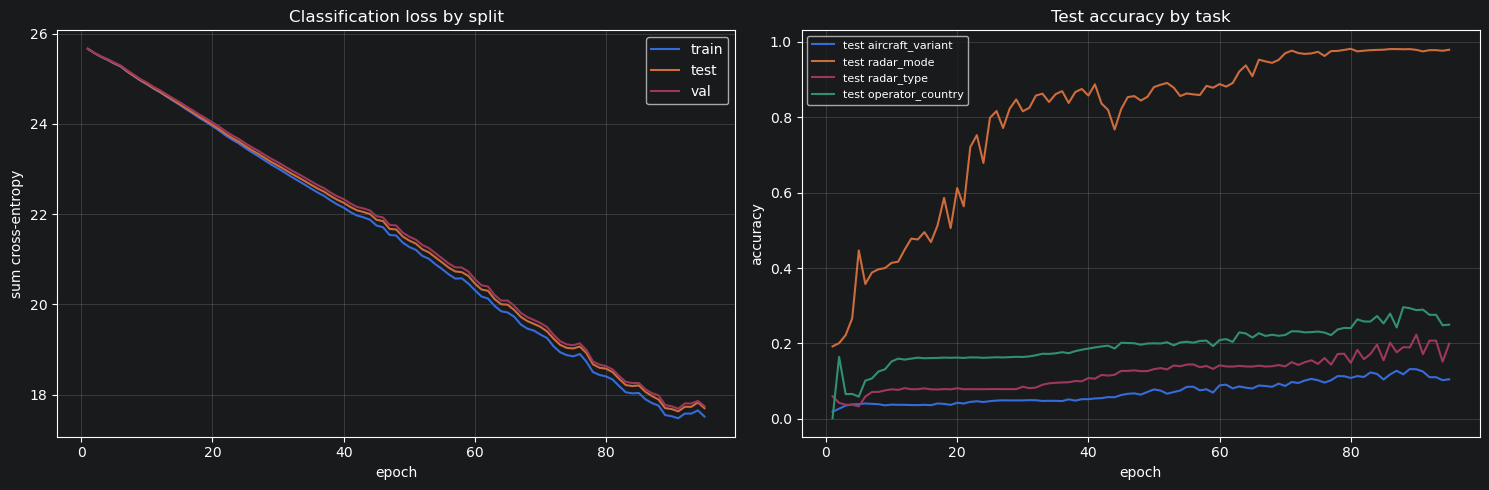

In [20]:
epochs = [r["epoch"] for r in history]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for split in ("train", "test", "val"):
    axes[0].plot(epochs, [r[f"{split}_loss"] for r in history], label=split)
axes[0].set_title("Classification loss by split")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("sum cross-entropy"); axes[0].legend(); axes[0].grid(True, alpha=.3)
for task in TARGETS:
    axes[1].plot(epochs, [r[f"test_{task}_acc"] for r in history], label=f"test {task}")
axes[1].set_title("Test accuracy by task")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=.3)
fig.tight_layout()
plot_path = ARTIFACT_DIR / "training_metrics.png"
fig.savefig(plot_path, dpi=150)
plot_path
